In [130]:
# Executar apenas uma vez:
# !pip install -r requirements.txt
# !python -m spacy download pt_core_news_sm

# Detectar linguas, para poder deixar apenas em portugues
# !pip install langdetect

In [131]:
# =========================
# IMPORTAÇÕES
# =========================

# Manipulação de dados
import pandas as pd
import numpy as np
from collections import Counter

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# NLP
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import RSLPStemmer
import spacy

# Vetorização
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Similaridade
from sklearn.metrics.pairwise import cosine_similarity

# WordCloud
from wordcloud import WordCloud

# Downloads necessários
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('rslp')

# Carregar modelo spaCy
nlp = spacy.load("pt_core_news_sm")

from langdetect import detect


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\unico\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\unico\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\unico\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package rslp to
[nltk_data]     C:\Users\unico\AppData\Roaming\nltk_data...
[nltk_data]   Package rslp is already up-to-date!


In [ ]:
# Baixa dataset automaticamente do Kaggle

# import kagglehub
# path = kagglehub.dataset_download("oliveirasp6/poems-in-portuguese")
# print("Path to dataset files:", path)

# Tarefa 1: Preparação e Análise Exploratória

In [ ]:
# - Entender estrutura dos dados
# - Ver distribuição de autores

# 1. Carregar o dataset
# df = pd.read_csv('../kaggle/input/poems-in-portuguese/portuguese-poems.csv', encoding='utf-8')
df = pd.read_csv('..\DATA\portuguese-poems.csv', encoding='utf-8')

In [134]:
# Verificação de qualidade dos dados
print("Valores nulos:\n", df.isnull().sum())
print("\nDuplicados:", df.duplicated().sum())
print("\nTipos:\n", df.dtypes)

Valores nulos:
 Author     0
Title      0
Content    2
Views      0
dtype: int64

Duplicados: 0

Tipos:
 Author     object
Title      object
Content    object
Views       int64
dtype: object


In [135]:
# Remoção dos nulos
df = df.dropna(subset = ['Content'])
print("Shape após remover nulos: ", df.shape)

Shape após remover nulos:  (15541, 4)


In [136]:
# O dataset contém mais de 15 mil poemas escritos por mais de 2000 autores.
# Após a remoção de valores nulos na coluna de conteúdo, restaram 15.541 poemas.
# Isso indica que o dataset possui boa qualidade e poucas inconsistências.

In [137]:
# 2. Explorar estrutura
print(f"Shape: {df.shape}")
print(f"Colunas: {df.columns.tolist()}")
df.head(10)

Shape: (15541, 4)
Colunas: ['Author', 'Title', 'Content', 'Views']


,Author,Title,Content,Views
0,Cecília Meireles,Retrato,"Eu não tinha este rosto de hoje,\r\nAssim calm...",1018431
1,Fernando Pessoa,"Para ser grande, sê inteiro: nada","Para ser grande, sê inteiro: nada\r\nTeu exage...",1979413
2,Marina Colasanti,"Eu sei, mas não devia",Eu sei que a gente se acostuma. Mas não devia....,301509
3,Carlos Drummond de Andrade,Quadrilha,João amava Teresa que amava Raimundo\r\nque am...,1421206
4,Eugénio de Andrade,É urgente o amor,É urgente o amor.\r\nÉ urgente um barco no mar...,621197
5,Vinicius de Moraes,Procura-se um amigo,"Não precisa ser homem, basta ser humano, basta...",942385
6,Fernando Pessoa,X. MAR PORTUGUÊS,"Ó mar salgado, quanto do teu sal\r\nSão lágrim...",1979414
7,Vinicius de Moraes,Eu sei e você sabe,Eu sei e você sabe\r\nJá que a vida quis assim...,942386
8,Gonçalves Dias,Como eu te amo,"Como se ama o silêncio, a luz, o aroma,\r\nO o...",581009
9,Manuel Bandeira,Poema tirado de uma notícia de jornal,João Gostoso era carregador de feira livre e m...,863828


In [138]:
# 3. Listar todos os autores
autores_unicos = df['Author'].unique()
print(f"Total de autores: {len(autores_unicos)}")
print(autores_unicos[:20])

Total de autores: 2127
['Cecília Meireles' 'Fernando Pessoa' 'Marina Colasanti'
 'Carlos Drummond de Andrade' 'Eugénio de Andrade' 'Vinicius de Moraes'
 'Gonçalves Dias' 'Manuel Bandeira' 'Sophia de Mello Breyner Andresen'
 'Chacal' 'Miguel Torga' 'Clarice Lispector' 'Thiago de Mello'
 'Bertolt Brecht' 'Florbela Espanca' 'João Roiz de Castelo-Branco'
 'Mário de Sá-Carneiro' "Alexandre O'Neill" 'José Gomes Ferreira'
 'Sebastião da Gama']


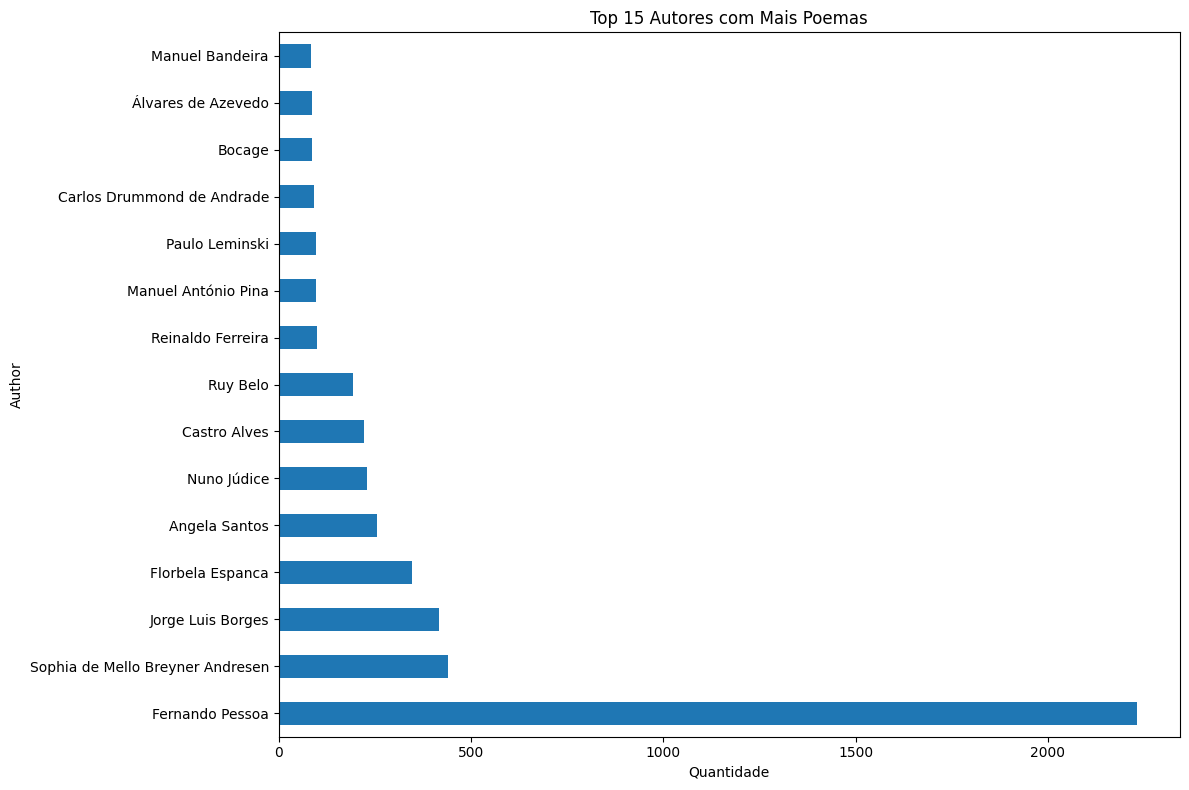

In [139]:
# 4. Visualizar distribuição
plt.figure(figsize=(12, 8))
df['Author'].value_counts().head(15).plot(kind='barh')
plt.xlabel('Número de Poemas')
plt.title('Top 15 Autores com Mais Poemas')
plt.xlabel('Quantidade')
plt.tight_layout()
plt.savefig('autores_distribution.png', dpi=150)
plt.show()

In [141]:
# O dataset possui grande diversidade de autores (mais de 2000).
# No entanto, existe forte concentração em alguns autores,
# especialmente Fernando Pessoa, que possui mais de 2200 poemas.
#
# Essa concentração pode influenciar análises estatísticas,
# pois autores com mais poemas tendem a dominar as frequências de palavras.

In [140]:
# Observa-se uma grande desigualdade na distribuição de poemas entre os autores.
# Esse tipo de distribuição indica que o dataset é fortemente desbalanceado. Podendo impactar análises baseadas em frequência
# Ex: TF, word clouds, vocabulário global
# Esse desequilíbrio justifica a decisão de filtrar autores específicos e balanceamento para análise comparativa, 
# permitindo observar diferenças estilísticas sem que um único autor domine as estatísticas globais.

In [142]:
# 6. Filtrar autores selecionados
selecionados = ['Fernando Pessoa', 'Florbela Espanca', 'Sophia de Mello Breyner Andresen']
df_pessoa = df[df['Author'].isin(selecionados)].copy()

print(f"\nPoemas de Fernando Pessoa, Florbela Espanca e Sophia de Mello Breyner Andresen: {len(df_pessoa)}")
print(df_pessoa['Author'].value_counts())


Poemas de Fernando Pessoa, Florbela Espanca e Sophia de Mello Breyner Andresen: 3020
Author
Fernando Pessoa                     2232
Sophia de Mello Breyner Andresen     441
Florbela Espanca                     347
Name: count, dtype: int64


Fernando Pessoa
<br>
A poesia de Fernando Pessoa é marcada pela diversidade de estilos devido ao uso de heterônimos, cada um com características próprias. Seus poemas exploram temas como existencialismo, identidade, emoção e reflexão filosófica. O ortônimo apresenta forte introspecção e o conceito de “fingimento poético”, enquanto seus heterônimos representam visões diferentes da realidade: Alberto Caeiro valoriza a simplicidade e a natureza, Álvaro de Campos expressa emoções intensas e modernistas, e Ricardo Reis adota uma poesia clássica e estoica.
<br>
Temas Comuns:
Melancolia e Amor: Melancolia e dor pela perda afetiva são frequentes.
Nacionalismo Crítico: Pessoa também utiliza a poesia para fazer uma análise crítica de Portugal.
Modernismo: A obra é marcada pela liberdade formal e estilo provocativo. 


Florbela Espanca
<br>
A poesia de Florbela Espanca é conhecida pelo lirismo intenso e confessional, com forte presença do “eu” poético. Seus poemas abordam temas como amor, desejo, solidão, saudade e sofrimento, frequentemente expressos em sonetos de grande técnica literária. Sua obra também destaca a voz feminina na literatura, explorando emoções profundas e reflexões sobre a existência e a morte.

Sophia de Mello Breyner Andresen
<br>
A poesia de Sophia de Mello Breyner Andresen caracteriza-se por uma linguagem clara e precisa, com forte ligação à natureza, especialmente ao mar. Seus poemas exploram temas como beleza, justiça, liberdade, tempo e existência, muitas vezes com inspiração clássica e mitológica. Sua obra também inclui poesia social e política, além de uma escrita que valoriza a simplicidade e a observação do cotidiano.

In [143]:
# Balanceamento do dataset
n_amostras = 340

df_balanceado = (
    df_pessoa
    .groupby('Author', group_keys=False)
    .apply(lambda x: x.sample(n=min(len(x), n_amostras), random_state=42))
)

print(df_balanceado['Author'].value_counts())

Author
Fernando Pessoa                     340
Florbela Espanca                    340
Sophia de Mello Breyner Andresen    340
Name: count, dtype: int64


C:\Users\unico\AppData\Local\Temp\ipykernel_10608\871333058.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(len(x), n_amostras), random_state=42))


In [144]:
# Detectar se o texto está em portugues e manter
def eh_portugues(texto):
    try:
        return detect(texto) == 'pt'
    except:
        return False

df_balanceado = df_balanceado[df_balanceado['Content'].apply(eh_portugues)]

# Tarefa 2: Pré-processamento de Texto em Português

In [ ]:
# Etapas:
# - Lowercase
# - Remoção de pontuação
# - Remoção de números
# - Tokenização
# - Remoção de stopwords

In [ ]:
# Limpeza de prepocessamento

def preprocessar(texto):
  # Converte todo o texto para minúsculas evitando que "Amor" e "amor" sejam tratados como palavras diferentes
  texto = texto.lower()
  # Limpar pontuações e caracteres
  texto = re.sub(r'[,.:;!?\'"-()\\[\\}{}]]', ' ', texto)
  # Remover digítos
  texto = re.sub(r'\d+', '', texto)
  # Diminuir espaços em branco
  texto = re.sub(r'\s+', ' ', texto)

  return texto

df_balanceado['texto_limpo'] = df_balanceado['Content'].apply(preprocessar)

# Esta etapa realiza a normalização inicial do texto.
# Ao remover pontuações, números e padronizar para minúsculas,
# evitamos que variações superficiais afetem a análise de frequência
# e os cálculos de TF e TF-IDF.


In [ ]:
# Carregar stopwords português
sw_pt = set(stopwords.words('portuguese'))

stop_words = sw_pt | set(['sophia', 'de', 'mello', 'breyner', 'andresen', 'the', 'and', 'of', 'in', 'moraes', 'pág', 'editor', 'círculo', 'antologiar', 'edição', 'editora'])

In [148]:
# 3. Tokenização e remoção de stopwords
def remover_stopwords(texto):
    # Tokenização: transforma o texto em lista de palavras
    tokens = word_tokenize(texto, language='portuguese')
    # Remove stopwords e tokens muito curtos
    return [token for token in tokens if token not in stop_words and len(token) > 2]

df_balanceado['tokens'] = df_balanceado['texto_limpo'].apply(remover_stopwords)
df_balanceado['num_tokens'] = df_balanceado['tokens'].apply(len)

# Stopwords são palavras muito frequentes na língua (ex: "de", "a", "o", "que").
# Elas geralmente não contribuem para identificar temas ou estilos.
# Removê-las ajuda a destacar palavras mais informativas do texto.

In [149]:
# 4. Comparação de impacto
tokens_antes = df_balanceado['texto_limpo'].apply(
    lambda x: len(word_tokenize(x, language='portuguese'))).mean()
tokens_depois = df_balanceado['num_tokens'].mean()

print(f"Média de tokens ANTES remover stopwords: {tokens_antes:.2f}")
print(f"Média de tokens APÓS remover stopwords: {tokens_depois:.2f}")
print(f"Redução: {((tokens_antes - tokens_depois) / tokens_antes * 100):.2f}%")

Média de tokens ANTES remover stopwords: 97.75
Média de tokens APÓS remover stopwords: 45.51
Redução: 53.45%


In [ ]:
# A remoção de stopwords reduziu aproximadamente 53.45% dos tokens.
# Isso mostra que grande parte do texto é composta por palavras
# funcionais da língua (como artigos, preposições e conjunções).
#
# Essa etapa é importante para destacar palavras com maior
# conteúdo semântico na análise textual.

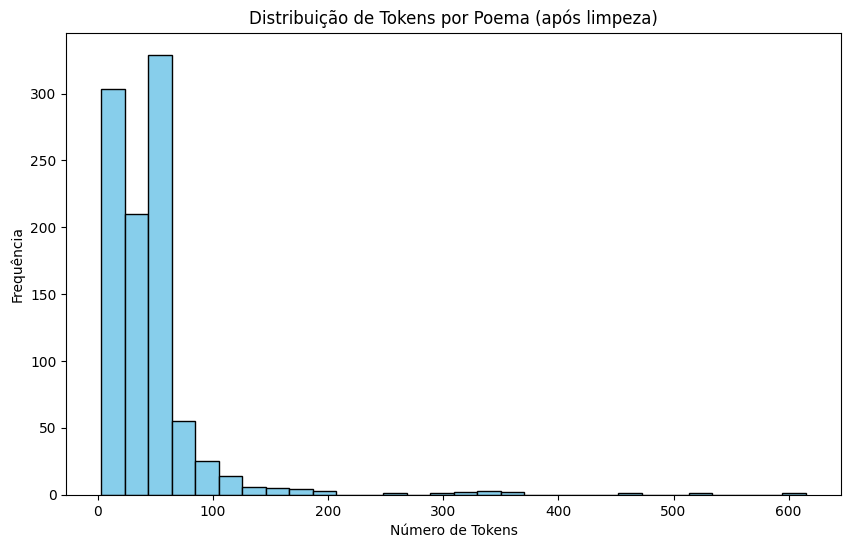

In [151]:
# 5. Visualizar distribuição
plt.figure(figsize=(10, 6))
plt.hist(df_balanceado['num_tokens'], bins=30, edgecolor='black', color='skyblue')
plt.xlabel('Número de Tokens')
plt.ylabel('Frequência')
plt.title('Distribuição de Tokens por Poema (após limpeza)')
plt.savefig('tokens_distribution.png', dpi=150)
plt.show()

In [ ]:
# Análise da distribuição de tokens
# A maioria dos poemas possui entre 20 e 100 tokens após o pré-processamento.
# A distribuição apresenta assimetria positiva, com alguns poemas muito longos
# (outliers) ultrapassando 100 tokens. Esse comportamento é comum em datasets
# de poesia e justifica o uso de técnicas como TF-IDF para normalizar o impacto
# de documentos maiores nas análises de frequência.

In [153]:
# =========================
# NORMALIZAÇÃO DE TEXTO
# =========================
# Stemming: reduz palavras ao radical
# Lematização: reduz para forma base (mais precisa)

In [154]:
# O stemmer RSLP é específico para português
stemmer = RSLPStemmer()

In [155]:
# O stemming reduz palavras ao seu radical
def aplicar_stemming(tokens):
  return [stemmer.stem(t) for t in tokens]

# Retorna o lema de cada palavra
def aplicar_lematizacao(texto):
  # Processa o texto com o modelo linguístico
  documentos = nlp(texto)
  # Retorna o lema de cada palavra
      
  return [
          token.lemma_
          for token in documentos
          if token.is_alpha 
          and not token.is_stop 
          and token.lemma_ not in stop_words
    ]

df_balanceado['tokens_stem'] = df_balanceado['tokens'].apply(aplicar_stemming)
df_balanceado['tokens_lemma'] = df_balanceado['texto_limpo'].apply(aplicar_lematizacao)

df_balanceado['texto_stem'] = df_balanceado['tokens_stem'].apply(lambda x: ' '.join(x))
df_balanceado['texto_lemma'] = df_balanceado['tokens_lemma'].apply(lambda x: ' '.join(x))

# O stemming reduz diferentes variações de uma palavra ao mesmo radical.
#
# Isso ajuda a agrupar palavras com o mesmo significado,
# mas pode gerar radicais que não existem como palavras reais.

# A lematização reduz palavras à sua forma canônica (lemma).
# Exemplos: amando -> amar
#
# Diferente do stemming, a lematização mantém palavras reais da língua,
# tornando os resultados mais interpretáveis semanticamente.

# Para uma analise de texto se faz mais sentido o uso da lemmatização, para casos de busca, velocidade seria melhor utilizar o stemming


In [156]:
# Após a lemmatização, a media de tokens unicos sao de 31.5
print(df_balanceado['tokens_lemma'].apply(set).apply(len).mean())

31.43271221532091


In [157]:
print("COMPARAÇÃO:")

for i in range(10,12):
    print("\nORIGINAL:", df_balanceado['Content'].iloc[i][:100])
    print("\nBASE:", df_balanceado['texto_limpo'].iloc[i][:100])
    print("STEM:", df_balanceado['texto_stem'].iloc[i][:100])
    print("LEMMA:", df_balanceado['texto_lemma'].iloc[i][:100])

COMPARAÇÃO:

ORIGINAL: A rosa que se não colhe
Nem por isso tem mais vida.
Ninguém há que te não olhe
Que te não queira 

BASE: a rosa que se não colhe nem por isso tem mais vida. ninguém há que te não olhe que te não queira col
STEM: ros colh vid ninguém olh que colh
LEMMA: roso colher vida ninguém olhar querer colher

ORIGINAL: Ó mera brancura
Do luar que se esfolha,
Ó     rio da alvura 
Do luar que te molha -

Montanhas que

BASE: ó mera brancura do luar que se esfolha, ó rio da alvura do luar que te molha - montanhas que ao long
STEM: mer branc lu esfolh rio alvur lu molh montanh long têm grit tod mong claustr infinit murmúri águ lu 
LEMMA: ó mero brancura luar esfolhar ó rio alvura luar molha montanha grito monge claustro infinito murmúri


# Tarefa 3: Vetorização com TF (CountVectorizer)

In [ ]:
# BAG OF WORDS (TF)
# Conta frequência das palavras

In [159]:
# 1. Preparar textos limpos como strings
textos = df_balanceado['texto_lemma'].values

In [160]:
# 2. CountVectorizer com unigramas, cria uma matriz de frequência de termos
vectorizer_tf = CountVectorizer(
    lowercase=True,
    stop_words= list(stop_words),
    ngram_range=(1, 1),
    max_features=100
)

In [161]:
# 3. Treinar e transformar
# Ajusta o modelo aos textos e gera a matriz
X_tf = vectorizer_tf.fit_transform(textos)

feature_names = vectorizer_tf.get_feature_names_out()

In [ ]:
# 4. Calcular frequências
# Soma as frequências de cada termo
term_freq = np.asarray(X_tf.sum(axis=0)).flatten()

term_freq_sorted = sorted(zip(feature_names, term_freq),
                        key=lambda x: x[1], reverse=True)

# TF mede quantas vezes cada palavra aparece no conjunto de textos.
# Palavras com alta frequência podem indicar temas recorrentes
# ou elementos característicos do estilo do autor.

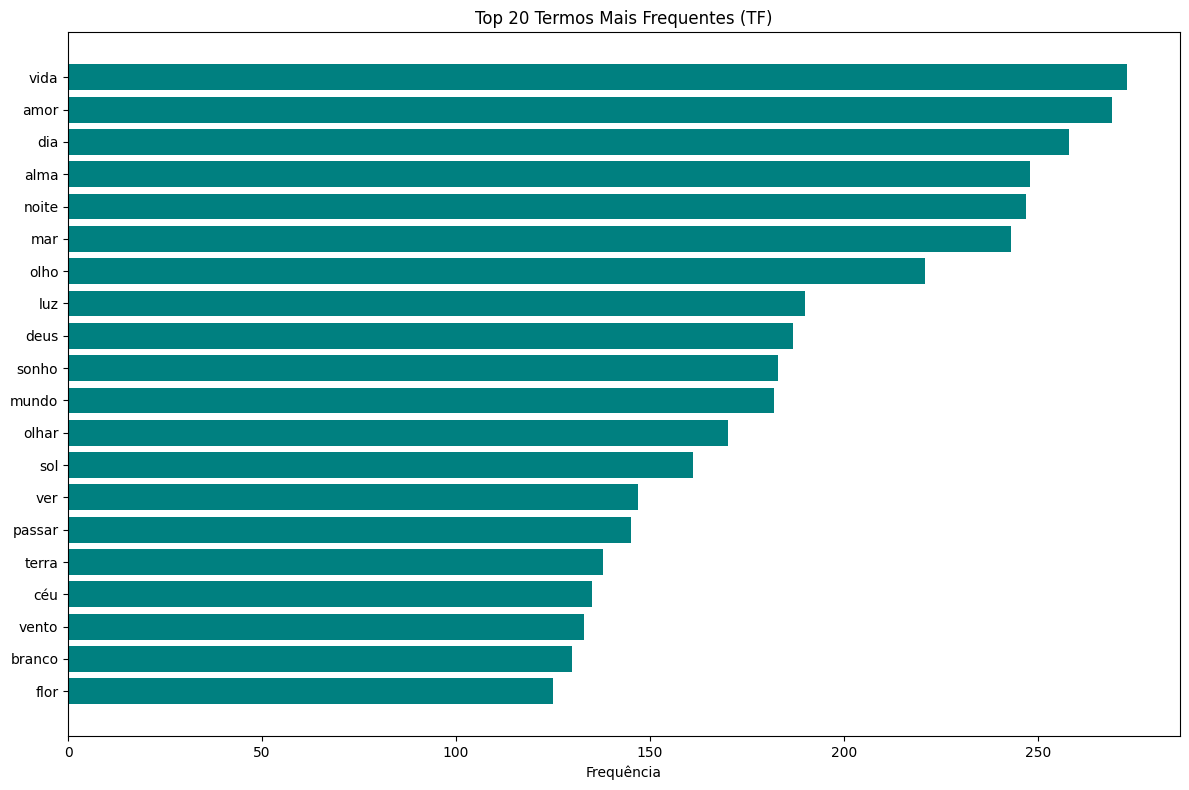

In [163]:
# 6. Visualizar
top_20 = term_freq_sorted[:20]
termos = [t[0] for t in top_20]
freqs = [t[1] for t in top_20]

plt.figure(figsize=(12, 8))
plt.barh(termos, freqs, color='teal')
plt.xlabel('Frequência')
plt.title('Top 20 Termos Mais Frequentes (TF)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('top_terms_tf_unigrams.png', dpi=150)
plt.show()

In [164]:
#A análise de frequência (TF) revelou forte presença de palavras funcionais da língua inglesa,
#  como “the”, “and” e “of”, indicando que o corpus contém poemas multilíngues 
# ou traduzidos. Esse fator introduz ruído na análise, podendo comprometer a interpretação dos padrões linguísticos.

#Ainda assim, termos como “vida”, “alma” e “mundo” aparecem com alta frequência,
#  sugerindo que os poemas abordam temas existenciais e subjetivos,
#  característicos da poesia lírica.

In [165]:
# 7. Bigramas
print("\n=== Bigramas Mais Frequentes ===")

vectorizer_bigram = CountVectorizer(
    lowercase=True,
    stop_words=list(stop_words),
    ngram_range=(2, 2),
    max_features=100
)

X_bigram = vectorizer_bigram.fit_transform(textos)

bigram_names = vectorizer_bigram.get_feature_names_out()

bigram_freq = np.asarray(X_bigram.sum(axis=0)).flatten()

bigram_sorted = sorted(zip(bigram_names, bigram_freq),
                    key=lambda x: x[1], reverse=True)

for i, (bigrama, freq) in enumerate(bigram_sorted[:10], 1):
    print(f"{i:2d}. {bigrama:25s} : {int(freq):3d}")


=== Bigramas Mais Frequentes ===
 1. dia mar                   :  49
 2. mar ático                 :  34
 3. ilha texto                :  22
 4. nome coisa                :  21
 5. amor amor                 :  10
 6. amar amar                 :   8
 7. azul céu                  :   8
 8. céu terra                 :   8
 9. noite escuro              :   8
10. beijo boca                :   7


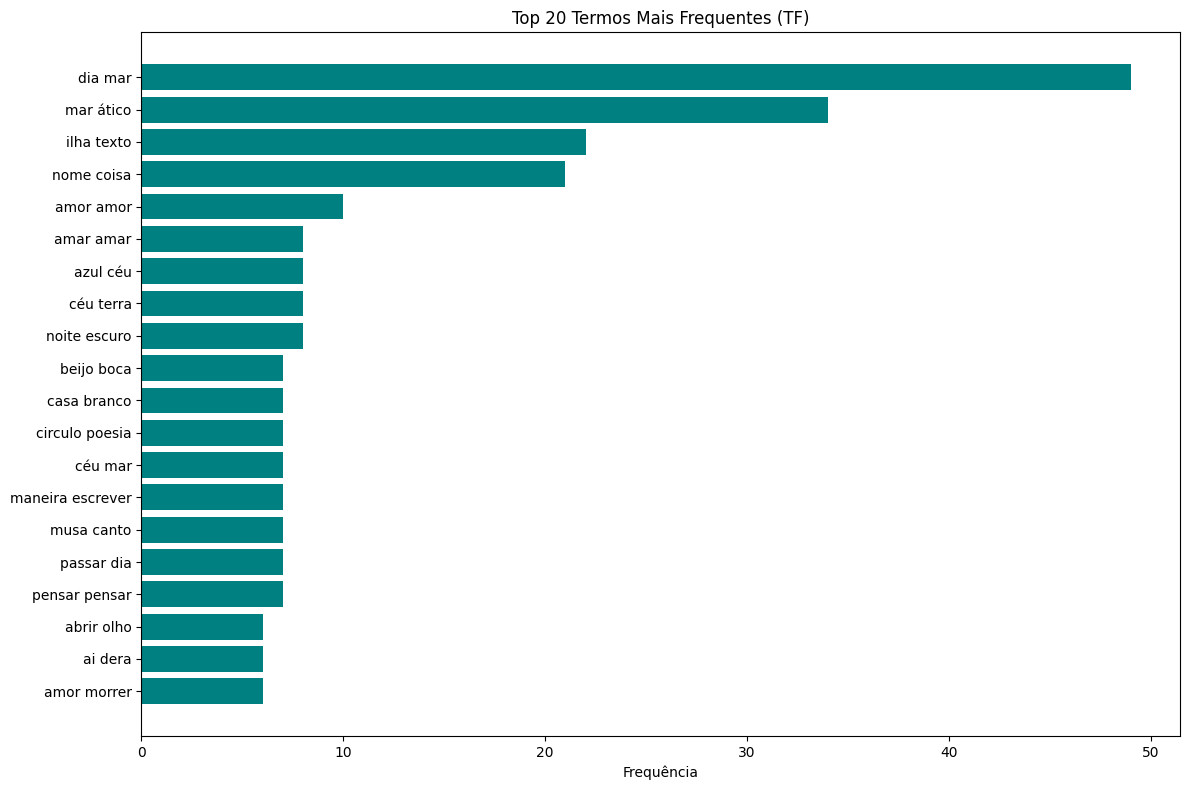

In [166]:
top_20 = bigram_sorted[:20]
termos = [t[0] for t in top_20]
freqs = [t[1] for t in top_20]

plt.figure(figsize=(12, 8))
plt.barh(termos, freqs, color='teal')
plt.xlabel('Frequência')
plt.title('Top 20 Termos Mais Frequentes (TF)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('top_terms_tf_unigrams.png', dpi=150)
plt.show()

In [167]:
def top_tf(textos):
    vectorizer = CountVectorizer(max_features=15)
    X = vectorizer.fit_transform(textos)
    names = vectorizer.get_feature_names_out()
    freq = np.asarray(X.sum(axis=0)).flatten()
    sorted_terms = sorted(zip(names, freq), key=lambda x: x[1], reverse=True)

    for t, f in sorted_terms[:10]:
        print(f"{t:25s} : {int(f):3d}")

print("\nTF ORIGINAL:")
top_tf(df_balanceado['texto_limpo'])

print("\nTF STEM:")
top_tf(df_balanceado['texto_stem'])

print("\nTF LEMMA:")
top_tf(df_balanceado['texto_lemma'])


TF ORIGINAL:
que                       : 2912
de                        : 2754
não                       : 996
do                        : 954
em                        : 916
se                        : 840
me                        : 830
um                        : 798
os                        : 789
da                        : 703

TF STEM:
olh                       : 410
am                        : 366
tod                       : 355
alm                       : 304
mim                       : 295
ond                       : 295
vid                       : 278
sonh                      : 273
mar                       : 268
dia                       : 267

TF LEMMA:
vida                      : 273
amor                      : 269
andresen                  : 263
dia                       : 258
alma                      : 248
noite                     : 247
mar                       : 243
olho                      : 221
de                        : 220
luz                       : 190


# Tarefa 4: Vetorização com TF-IDF

In [169]:
# =========================
# TF-IDF
# =========================
# Mede importância da palavra no corpus

In [170]:
# 1. TfidfVectorizer
vectorizer_tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words=list(stop_words),
    ngram_range=(1, 1),
    max_features=500,
    norm='l2'
)

In [171]:
# 2. Treinar e transformar
X_tfidf = vectorizer_tfidf.fit_transform(textos)
tfidf_names = vectorizer_tfidf.get_feature_names_out()

In [172]:
# 3. Calcular scores TF-IDF globais
tfidf_scores = np.asarray(X_tfidf.sum(axis=0)).flatten()
tfidf_sorted = sorted(zip(tfidf_names, tfidf_scores),
                    key=lambda x: x[1], reverse=True)

print("=== Top 15 Termos por TF-IDF (Global) ===")
for i, (termo, score) in enumerate(tfidf_sorted[:15], 1):
    print(f"{i:2d}. {termo:15s} : {score:.6f}")

# TF-IDF identifica palavras importantes considerando dois fatores:
#
# TF (Term Frequency):
# quantas vezes a palavra aparece
#
# IDF (Inverse Document Frequency):
# quão rara a palavra é no conjunto de documentos
#
# Isso faz com que palavras comuns em todos os poemas tenham
# peso menor, enquanto palavras distintivas ganham maior relevância.

=== Top 15 Termos por TF-IDF (Global) ===
 1. dia             : 36.304042
 2. amor            : 34.951708
 3. mar             : 32.593660
 4. vida            : 31.707726
 5. noite           : 30.700352
 6. olho            : 28.480600
 7. alma            : 28.215337
 8. deus            : 24.776014
 9. olhar           : 24.712383
10. luz             : 23.778527
11. poesia          : 23.192365
12. sonho           : 22.797541
13. mundo           : 22.665242
14. ti              : 22.534111
15. sol             : 21.518991


In [173]:
# Diferentemente do TF, o TF-IDF destacou palavras com maior
# relevância semântica nos poemas, como "vida", "alma", "coração".
#
# Isso ocorre porque o TF-IDF penaliza palavras muito frequentes
# no corpus e valoriza termos que aparecem em contextos mais específicos.
#
# Dessa forma, o TF-IDF tende a capturar melhor temas recorrentes
# da poesia, como sentimentos, existência e subjetividade.

In [174]:
# Comparação STEM vs LEMMA
def top_tfidf(textos):
    vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words=list(stop_words),
    ngram_range=(1, 1),
    max_features=500,
    norm='l2'
)
    X = vectorizer.fit_transform(textos)
    feature_names = vectorizer.get_feature_names_out()
    tfidf_scores = np.asarray(X.sum(axis=0)).flatten()
    tfidf_sorted =  sorted(zip(feature_names, tfidf_scores),
                    key=lambda x: x[1], reverse=True)
    for i, (termo, score) in enumerate(tfidf_sorted[:15], 1):
      print(f"{i:2d}. {termo:15s} : {score:.6f}")

print("TF-IDF ORIGINAL:", top_tfidf(df_balanceado['texto_limpo']))
print("\nTF-IDF STEM:", top_tfidf(df_balanceado['texto_stem']))
print("\nTF-IDF LEMMA:", top_tfidf(df_balanceado['texto_lemma']))

 1. amor            : 33.187194
 2. mar             : 32.037555
 3. dia             : 31.261254
 4. vida            : 30.508107
 5. mim             : 28.865981
 6. tudo            : 28.255637
 7. noite           : 27.583064
 8. alma            : 27.177143
 9. olhos           : 26.692904
10. onde            : 26.281525
11. nada            : 22.829507
12. luz             : 22.588698
13. sol             : 21.880340
14. tão             : 21.728435
15. tempo           : 21.036176
TF-IDF ORIGINAL: None
 1. olh             : 38.937532
 2. am              : 36.940830
 3. mar             : 30.814370
 4. tod             : 30.752109
 5. dia             : 30.747051
 6. ond             : 28.398858
 7. alm             : 28.220033
 8. noit            : 28.092660
 9. vid             : 27.960211
10. sonh            : 27.651900
11. mim             : 27.558231
12. pass            : 26.783411
13. tud             : 26.005960
14. soph            : 23.721021
15. luz             : 22.781304

TF-IDF STEM: None

In [175]:
# Comparação entre stemming e lematização
#
# O stemming reduz palavras para radicais, o que pode gerar formas
# que não existem no idioma, mas ajuda a agrupar variações rapidamente.
#
# A lematização mantém palavras válidas da língua portuguesa,
# o que torna a interpretação dos resultados mais clara.
#
# Em análises exploratórias e visualizações (como wordcloud),
# a lematização tende a produzir resultados mais interpretáveis.

In [ ]:
# 4. Comparar TF vs TF-IDF por autor
print("\n=== Comparação TF vs TF-IDF por Autor ===")
for autor in selecionados:
    textos_autor = df_balanceado[df_balanceado['Author'] == autor]['texto_lemma'].values

    if len(textos_autor) > 0:
        # TF
        vect_tf_autor = CountVectorizer(
            lowercase=True,
            stop_words=list(stop_words),
            max_features=15
        )
        X_tf_autor = vect_tf_autor.fit_transform(textos_autor)
        tf_nomes = vect_tf_autor.get_feature_names_out()
        tf_freq = np.asarray(X_tf_autor.sum(axis=0)).flatten()
        tf_sorted = sorted(zip(tf_nomes, tf_freq), key=lambda x: x[1], reverse=True)

        # TF-IDF
        vect_tfidf_autor = TfidfVectorizer(
            lowercase=True,
            stop_words=list(stop_words),
            max_features=15,
            norm='l2'
        )
        X_tfidf_autor = vect_tfidf_autor.fit_transform(textos_autor)
        tfidf_nomes = vect_tfidf_autor.get_feature_names_out()
        tfidf_scores_autor = np.asarray(X_tfidf_autor.sum(axis=0)).flatten()
        tfidf_sorted_autor = sorted(zip(tfidf_nomes, tfidf_scores_autor),
                                key=lambda x: x[1], reverse=True)

        print(f"\n{'='*50}")
        print(f"AUTOR: {autor}")
        print(f"{'='*50}")
        print(f"{'Top 10 por TF':<35} | {'Top 10 por TF-IDF':<35}")
        print("-" * 72)
        for j in range(10):
            tf_item = f"{j+1}. {tf_sorted[j][0]}" if j < len(tf_sorted) else ""
            tfidf_item = f"{j+1}. {tfidf_sorted_autor[j][0]}" if j < len(tfidf_sorted_autor) else ""
            print(f"{tf_item:<35} | {tfidf_item:<35}")


=== Comparação TF vs TF-IDF por Autor ===

AUTOR: Fernando Pessoa
Top 10 por TF                       | Top 10 por TF-IDF                  
------------------------------------------------------------------------
1. vida                             | 1. vida                            
2. alma                             | 2. alma                            
3. deus                             | 3. deus                            
4. pensar                           | 4. dia                             
5. sentir                           | 5. ver                             
6. dia                              | 6. coração                         
7. ver                              | 7. pensar                          
8. noite                            | 8. sentir                          
9. pensamento                       | 9. noite                           
10. mundo                           | 10. sonho                          

AUTOR: Florbela Espanca
Top 10 por TF        

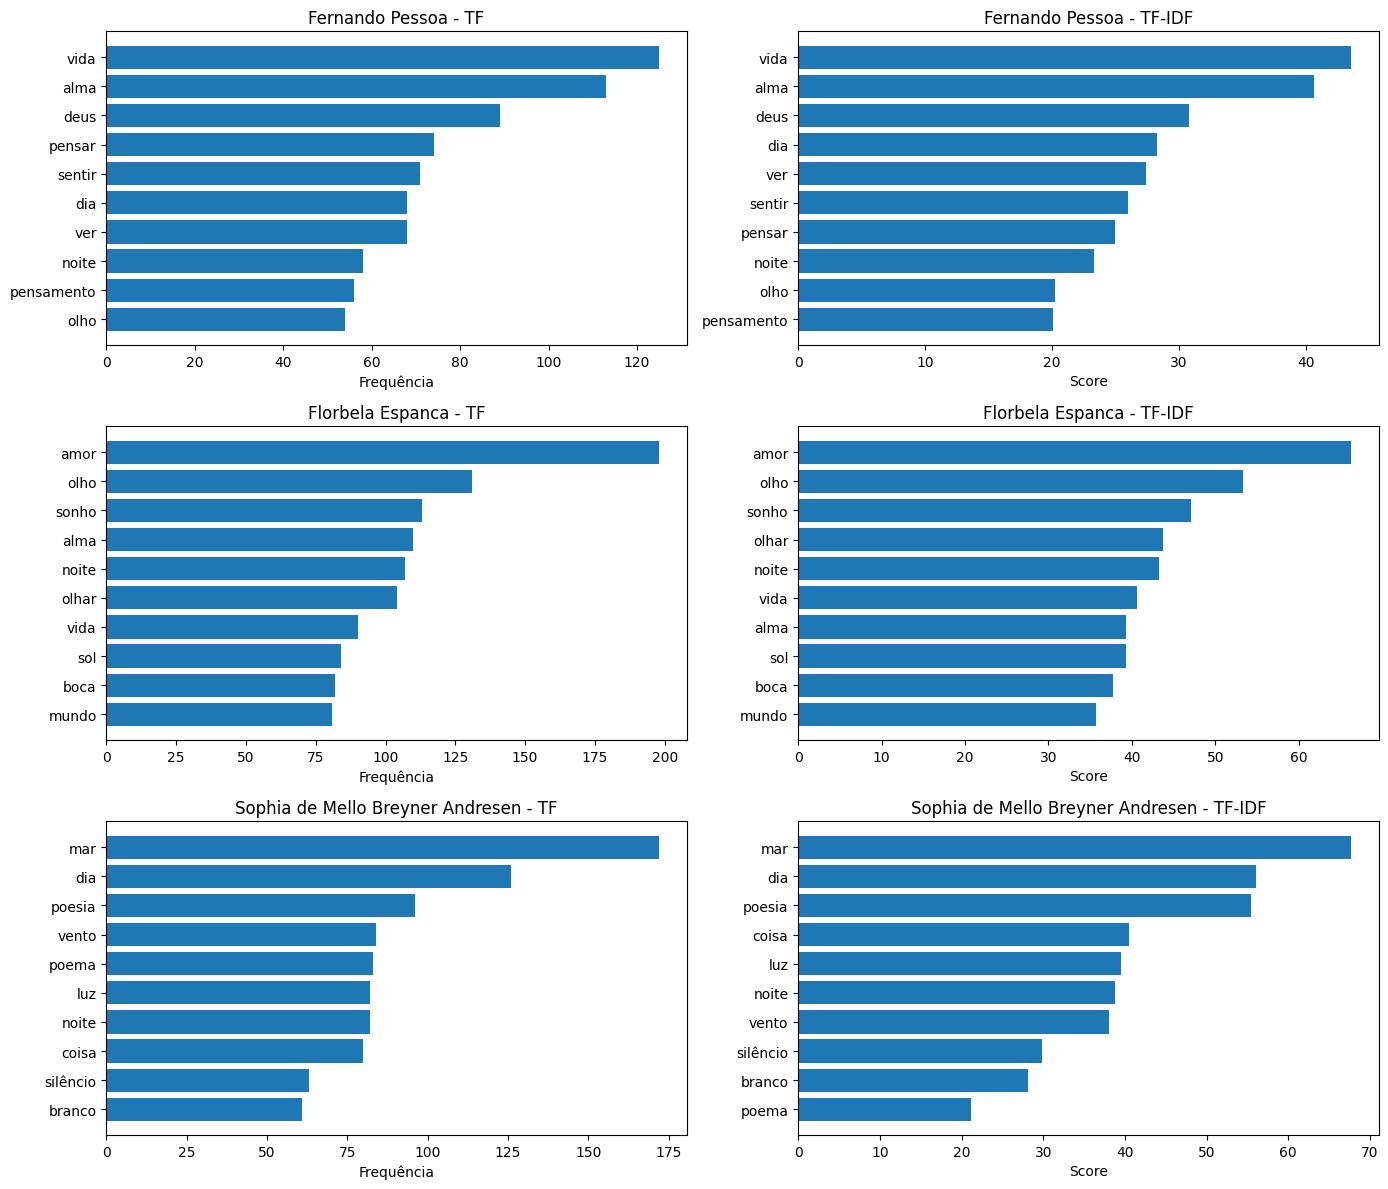

In [197]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

fig, axes = plt.subplots(len(selecionados), 2, figsize=(14, 12))

for i, autor in enumerate(selecionados):

    textos_autor = df_balanceado[df_balanceado['Author'] == autor]['texto_lemma'].values

    if len(textos_autor) > 0:

        # ================= TF =================
        vect_tf_autor = CountVectorizer(
            lowercase=True,
            stop_words=list(stop_words),
            max_features=10
        )

        X_tf_autor = vect_tf_autor.fit_transform(textos_autor)
        tf_nomes = vect_tf_autor.get_feature_names_out()
        tf_freq = np.asarray(X_tf_autor.sum(axis=0)).flatten()

        tf_sorted = sorted(zip(tf_nomes, tf_freq), key=lambda x: x[1], reverse=True)
        palavras_tf = [x[0] for x in tf_sorted]
        valores_tf = [x[1] for x in tf_sorted]

        axes[i, 0].barh(palavras_tf[::-1], valores_tf[::-1])
        axes[i, 0].set_title(f"{autor} - TF")
        axes[i, 0].set_xlabel("Frequência")

        # ================= TF-IDF =================
        vect_tfidf_autor = TfidfVectorizer(
            lowercase=True,
            stop_words=list(stop_words),
            max_features=10,
            norm='l2'
        )

        X_tfidf_autor = vect_tfidf_autor.fit_transform(textos_autor)
        tfidf_nomes = vect_tfidf_autor.get_feature_names_out()
        tfidf_scores = np.asarray(X_tfidf_autor.sum(axis=0)).flatten()

        tfidf_sorted = sorted(zip(tfidf_nomes, tfidf_scores), key=lambda x: x[1], reverse=True)
        palavras_tfidf = [x[0] for x in tfidf_sorted]
        valores_tfidf = [x[1] for x in tfidf_sorted]

        axes[i, 1].barh(palavras_tfidf[::-1], valores_tfidf[::-1])
        axes[i, 1].set_title(f"{autor} - TF-IDF")
        axes[i, 1].set_xlabel("Score")

plt.tight_layout()
plt.show()

In [177]:
# A comparação entre TF e TF-IDF mostra diferenças importantes:
#
# TF destaca palavras mais frequentes no corpus,
# incluindo palavras funcionais ou comuns.
#
# TF-IDF destaca palavras mais informativas,
# que ajudam a caracterizar melhor o conteúdo dos poemas.
#
# Assim, o TF é útil para identificar frequência,
# enquanto o TF-IDF é mais adequado para análise semântica.

In [178]:
# 5. Testar normalizações L1 vs L2
print("\n=== Comparação L1 vs L2 ===")
vect_l1 = TfidfVectorizer(norm='l1', max_features=100, lowercase=True, stop_words=list(stop_words))
vect_l2 = TfidfVectorizer(norm='l2', max_features=100, lowercase=True, stop_words=list(stop_words))

X_l1 = vect_l1.fit_transform(textos)
X_l2 = vect_l2.fit_transform(textos)

print(f"Norma L1 (Manhattan) - Soma de um vetor: {X_l1[0].sum():.6f}")
print(f"Norma L2 (Euclidiana) - Norma de um vetor: {np.sqrt((X_l2[0].data**2).sum()):.6f}")


=== Comparação L1 vs L2 ===
Norma L1 (Manhattan) - Soma de um vetor: 1.000000
Norma L2 (Euclidiana) - Norma de um vetor: 1.000000


In [179]:
# A normalização garante que todos os vetores TF-IDF tenham
# a mesma escala.
#
# A norma L1 normaliza pela soma dos valores,
# enquanto a norma L2 normaliza pela distância euclidiana.
#
# Ambas ajudam a evitar que documentos maiores dominem
# os cálculos de similaridade.

# Tarefa 5: Visualização com Word Clouds

In [ ]:
# WordCloud para interpretar frequências

Gerando word clouds por autor...
✓ Salvo: wordcloud_3_autores.png


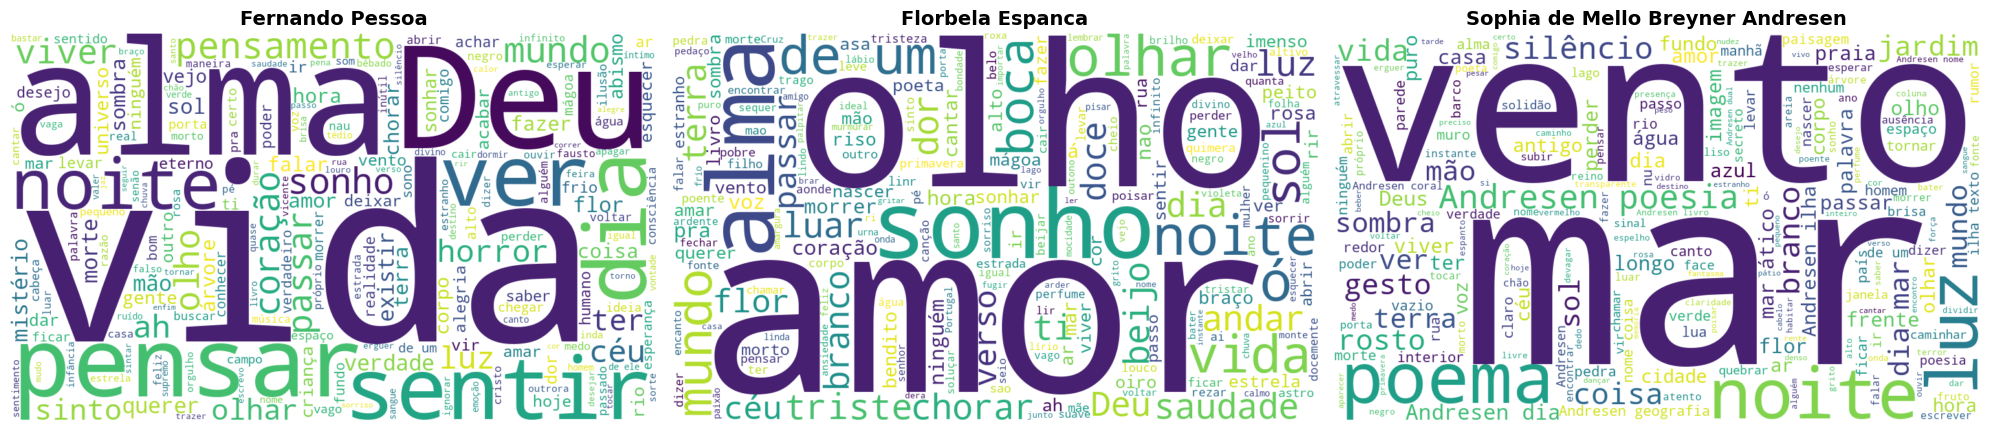

In [181]:
print("Gerando word clouds por autor...")

# Criar figura com 3 subplots (1 linha, 3 colunas)
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for i, autor in enumerate(selecionados[:3]):  # Garantir no máximo 3
    textos_autor = ' '.join(
        df_balanceado[df_balanceado['Author'] == autor]['texto_lemma'].values
    )

    if len(textos_autor) > 50:
        wc = WordCloud(
            width=1000,
            height=600,
            background_color='white',
            colormap='viridis',
            prefer_horizontal=0.7,
            random_state=42
        ).generate(textos_autor)

        axes[i].imshow(wc, interpolation='bilinear')
        axes[i].set_title(f'{autor}', fontsize=14, fontweight='bold')
        axes[i].axis('off')

# Ajustar layout
plt.tight_layout()

# Salvar imagem única com os 3 autores
plt.savefig('wordcloud_3_autores.png', dpi=150, bbox_inches='tight')
print("✓ Salvo: wordcloud_3_autores.png")

plt.show()

In [182]:
# A WordCloud permite visualizar rapidamente as palavras
# mais frequentes nos poemas de Fernando Pessoa.
#
# O tamanho de cada palavra representa sua frequência
# no conjunto de poemas analisados.
#
# Esse tipo de visualização facilita identificar temas
# recorrentes no estilo do autor.

✓ Salvo: wordcloud_tf_vs_tfidf_comparison.png


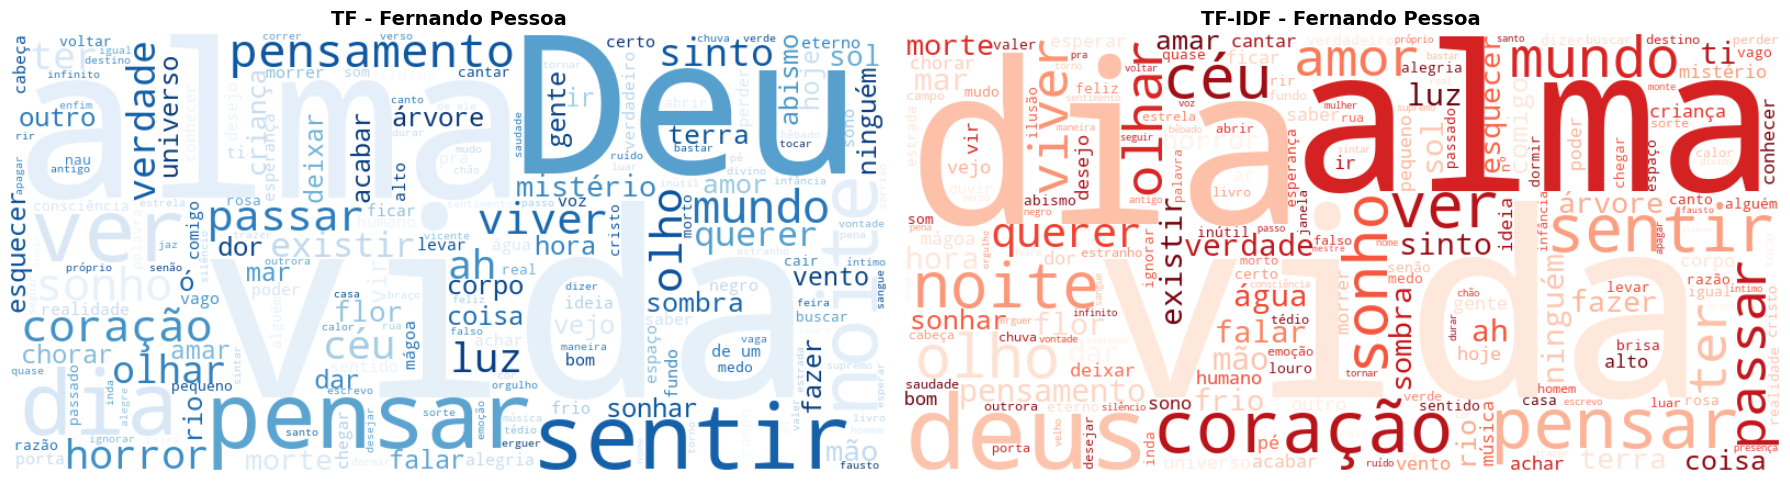

In [183]:
# 2. Word Cloud TF vs TF-IDF para um autor
autor_escolhido = 'Fernando Pessoa'
textos_escolhido_lista = df_balanceado[df_balanceado['Author'] == autor_escolhido]['texto_lemma'].values

# Mantém seu texto concatenado (TF usa isso)
textos_escolhido = ' '.join(textos_escolhido_lista)

if len(textos_escolhido) > 50:
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    # =========================
    # TF (igual ao seu)
    # =========================
    wc_tf = WordCloud(width=800, height=400, background_color='white',
                      colormap='Blues', random_state=42).generate(textos_escolhido)

    axes[0].imshow(wc_tf, interpolation='bilinear')
    axes[0].set_title(f'TF - {autor_escolhido}', fontsize=14, fontweight='bold')
    axes[0].axis('off')

    # =========================
    # TF-IDF (CORRIGIDO)
    # =========================
    vectorizer = TfidfVectorizer(
        stop_words= list(stop_words),
        max_features=200
    )

    X = vectorizer.fit_transform(textos_escolhido_lista)

    feature_names = vectorizer.get_feature_names_out()
    tfidf_scores = np.asarray(X.sum(axis=0)).flatten()

    tfidf_dict = dict(zip(feature_names, tfidf_scores))

    wc_tfidf = WordCloud(width=800, height=400, background_color='white',
                         colormap='Reds', random_state=42).generate_from_frequencies(tfidf_dict)

    axes[1].imshow(wc_tfidf, interpolation='bilinear')
    axes[1].set_title(f'TF-IDF - {autor_escolhido}', fontsize=14, fontweight='bold')
    axes[1].axis('off')

    plt.tight_layout()
    plt.savefig('wordcloud_tf_vs_tfidf_comparison.png', dpi=150, bbox_inches='tight')
    print("✓ Salvo: wordcloud_tf_vs_tfidf_comparison.png")

    plt.show()

In [184]:
# WordCloud TF vs TF-IDF
#
# O WordCloud baseado em TF mostra as palavras mais frequentes
# no conjunto de poemas.
#
# Já o WordCloud baseado em TF-IDF destaca palavras que são
# mais características de determinados poemas ou autores,
# reduzindo o peso de palavras muito comuns.
#
# Dessa forma, TF revela popularidade de termos,
# enquanto TF-IDF revela relevância contextual.

✓ Salvo: wordcloud_triplo_fernando_pessoa.png


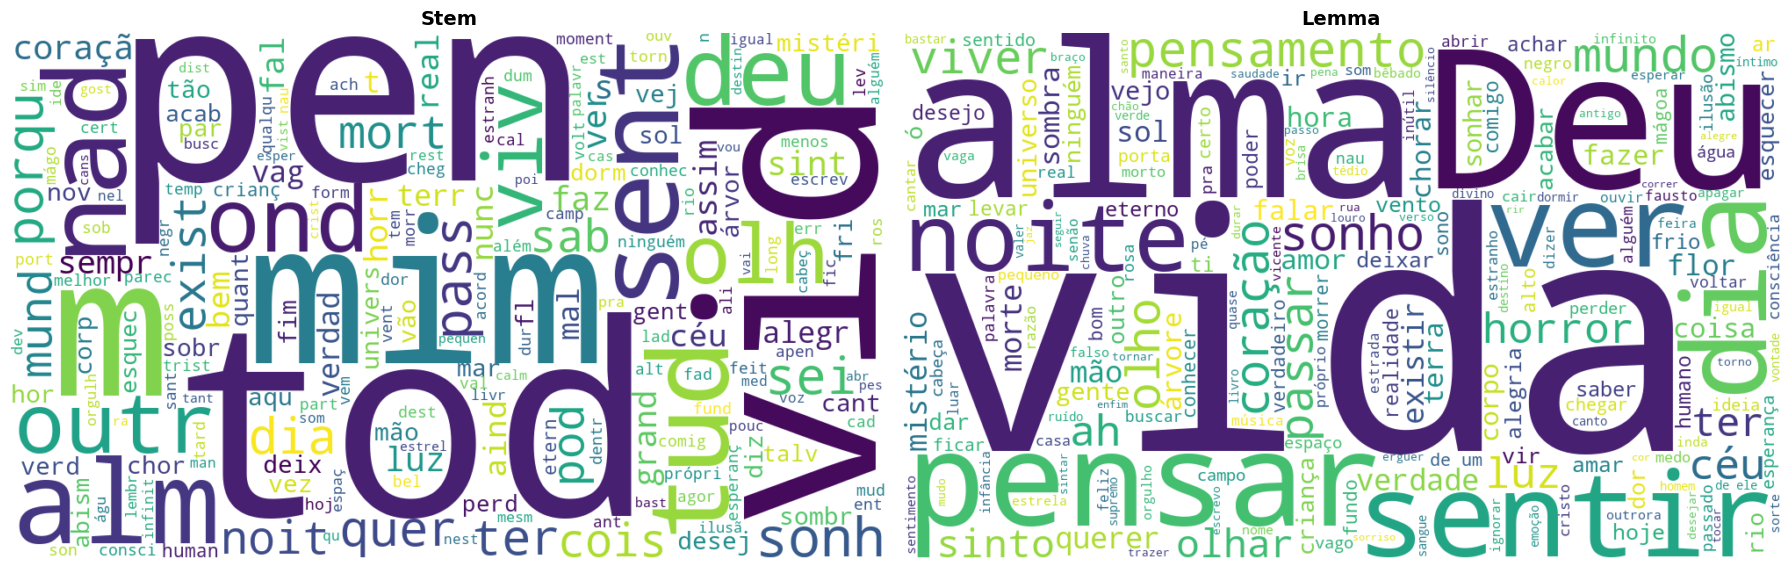

In [185]:
autor = 'Fernando Pessoa'

# Junta os textos
texto_limpo = ' '.join(df_balanceado[df_balanceado['Author']==autor]['texto_limpo'])
texto_stem  = ' '.join(df_balanceado[df_balanceado['Author']==autor]['texto_stem'])
texto_lemma = ' '.join(df_balanceado[df_balanceado['Author']==autor]['texto_lemma'])

# Configuração padrão (igual ao seu primeiro código)
wc_config = dict(
    width=1000,
    height=600,
    background_color='white',
    colormap='viridis',
    prefer_horizontal=0.7,
    random_state=42
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# # --- Original ---
# if len(texto_limpo) > 50:
#     wc1 = WordCloud(**wc_config).generate(texto_limpo)
#     axes[0].imshow(wc1, interpolation='bilinear')
#     axes[0].set_title("Texto Limpo", fontsize=14, fontweight='bold')

# --- Stem ---
if len(texto_stem) > 50:
    wc2 = WordCloud(**wc_config).generate(texto_stem)
    axes[0].imshow(wc2, interpolation='bilinear')
    axes[0].set_title("Stem", fontsize=14, fontweight='bold')

# --- Lemma ---
if len(texto_lemma) > 50:
    wc3 = WordCloud(**wc_config).generate(texto_lemma)
    axes[1].imshow(wc3, interpolation='bilinear')
    axes[1].set_title("Lemma", fontsize=14, fontweight='bold')

# Remove eixos
for ax in axes:
    ax.axis('off')

plt.tight_layout()

# Salvar igual ao outro padrão
filename = f'wordcloud_triplo_{autor.replace(" ", "_").lower()}.png'
plt.savefig(filename, dpi=150, bbox_inches='tight')

print(f"✓ Salvo: {filename}")

plt.show()

# Tarefa 6: Análise de Similaridade entre Poemas (Desafio)

In [186]:
# =========================
# SIMILARIDADE ENTRE POEMAS
# =========================
# Usa cosine similarity para medir proximidade semântica

In [187]:
# 1. Calcular matriz de similaridade
similarity_matrix = cosine_similarity(X_tfidf)

In [203]:
# 2. Selecionar um poema de referência
idx_campos = (df_balanceado['Author'] == 'Fernando Pessoa').values
indices_campos = np.where(idx_campos)[0]

if len(indices_campos) > 0:
    idx_referencia = indices_campos[6]
    similares = similarity_matrix[idx_referencia].argsort()[::-1][1:6]

    print(f"\n{'='*70}")
    print(f"POEMA DE REFERÊNCIA: {df_balanceado.iloc[idx_referencia]['Author']}")
    print(f"{'='*70}")
    print(f"{df_balanceado.iloc[idx_referencia]['texto_limpo'][:200]}...\n")

    print("POEMAS MAIS SIMILARES:")
    for i, idx_similar in enumerate(similares, 1):
        sim_score = similarity_matrix[idx_referencia, idx_similar]
        autor = df_balanceado.iloc[idx_similar]['Author']
        texto = df_balanceado.iloc[idx_similar]['texto_limpo'][:150]
        print(f"\n{i}. [{sim_score:.4f}] {autor}")
        print(f"   {texto}...")


POEMA DE REFERÊNCIA: Fernando Pessoa
deixaste cair a liga porque não estava apertada... por muito que a gente diga a gente nunca diz nada....

POEMAS MAIS SIMILARES:

1. [0.6417] Florbela Espanca
   amar a quem nos despreza e sina que a gente tem; eu desprezo quem m’odeia e adoro quem me quer bem. ...

2. [0.5225] Sophia de Mello Breyner Andresen
   esta gente cujo rosto às vezes luminoso e outras vezes tosco ora me lembra escravos ora me lembra reis faz renascer meu gosto de luta e de combate con...

3. [0.3651] Fernando Pessoa
   o ter deveres, que prolixa coisa! agora tenho eu que estar à uma menos cinco na estação do rossio, tabuleiro superior – despedida do amigo que vai no ...

4. [0.3532] Fernando Pessoa
   já ouvi doze vezes dar a hora no relógio que diz que é meio-dia a toda a gente que aqui perto mora. (o comentário é do camões agora:) «tanto que esper...

5. [0.3532] Fernando Pessoa
   opiário ao senhor mário de sá-carneiro é antes do ópio que a minh'alma é doente. sentir a

In [189]:
# A similaridade entre poemas foi calculada utilizando
# a métrica de similaridade do cosseno.
#
# Essa métrica mede o ângulo entre dois vetores TF-IDF,
# indicando o quanto dois poemas são semanticamente próximos.
#
# Valores próximos de 1 indicam alta similaridade,
# enquanto valores próximos de 0 indicam textos diferentes.

In [204]:
# 3. Comparar com outro autor (Florbela Espanca)
idx_reis = (df['Author'] == 'Florbela Espanca').values
indices_reis = np.where(idx_reis)[0]

if len(indices_reis) > 0:
    idx_ref_reis = indices_reis[1]
    similares_reis = similarity_matrix[idx_ref_reis].argsort()[::-1][1:6]

    print(f"\n{'='*70}")
    print(f"POEMA DE REFERÊNCIA: Florbela Espanca")
    print(f"{'='*70}")
    print(f"{df_balanceado.iloc[idx_ref_reis]['Content'][:200]}...\n")

    print("POEMAS MAIS SIMILARES:")
    for i, idx_sim in enumerate(similares_reis, 1):
        sim_score = similarity_matrix[idx_ref_reis, idx_sim]
        autor = df_balanceado.iloc[idx_sim]['Author']
        texto = df_balanceado.iloc[idx_sim]['texto_limpo'][:150]
        print(f"\n{i}. [{sim_score:.4f}] {autor}")
        print(f"   {texto}...")


POEMA DE REFERÊNCIA: Florbela Espanca
Qual, Pirro, aquilo gosta que o amarga,
        Qual aquilo que gosta.
Pares quem os fados diferentes
        Como rios diversos,
Com curso a leste ou oeste, a sul ou norte,
        Sempre ao mar...

POEMAS MAIS SIMILARES:

1. [0.6478] Fernando Pessoa
   lá por olhar para ti não julgues que é por gostar. eu gosto muito do sol, e nem o posso fitar....

2. [0.3850] Fernando Pessoa
   não sei que grande tristeza me fez só gostar de ti quando já tinha a certeza de te amar porque te vi....

3. [0.3206] Florbela Espanca
   o fado não é da terra, o fado criou-o deus, o fado é andar doidinha perdida pios olhos teus ...

4. [0.3164] Florbela Espanca
   tenho ódio à luz e raiva à claridade do sol, alegre, quente, na subida. parece que a minh’alma é perseguida por um carrasco cheio de maldade! ó minha ...

5. [0.2700] Florbela Espanca
   há no fado das vielas notas tão sentimentais, tão delicadas, tão belas, que não s’esquecem jamais! ...


In [191]:
# Conclusão da análise

# A comparação entre as técnicas mostrou que:

# - O pré-processamento reduz significativamente o ruído textual
# - A remoção de stopwords melhora a identificação de termos relevantes
# - O stemming agrupa variações de palavras, mas reduz interpretabilidade
# - A lematização preserva significado linguístico
# - TF destaca palavras frequentes
# - TF-IDF destaca palavras distintivas

# Essas técnicas combinadas permitem explorar padrões linguísticos
# e diferenças estilísticas entre autores.

In [192]:
# Sumário dos resultados
print("\n" + "="*70)
print("SUMÁRIO DA ANÁLISE")
print("="*70)

print(f"\n1. DATASET:")
print(f"   • Total de poemas: {len(df_balanceado)}")
print(f"   • Autores analisados: {selecionados}")
print(f"   • Distribuição: {dict(df_balanceado['Author'].value_counts())}")

print(f"\n2. VOCABULÁRIO:")
print(f"   • Termos únicos totais: {len(feature_names)}")
print(f"   • Termo mais frequente: '{term_freq_sorted[0][0]}' ({int(term_freq_sorted[0][1])} ocorrências)")
print(f"   • Comprimento médio de poema: {df_balanceado['num_tokens'].mean():.0f} tokens")

print(f"\n3. TERMOS DISCRIMINATIVOS (TF-IDF):")
print(f"   • Top 3 globais: {', '.join([t[0] for t in tfidf_sorted[:3]])}")

print(f"\n4. BIGRAMAS:")
print(f"   • Bigrama mais frequente: '{bigram_sorted[0][0]}' ({int(bigram_sorted[0][1])} ocorrências)")

print("\n" + "="*70 + "\n")


SUMÁRIO DA ANÁLISE

1. DATASET:
   • Total de poemas: 966
   • Autores analisados: ['Fernando Pessoa', 'Florbela Espanca', 'Sophia de Mello Breyner Andresen']
   • Distribuição: {'Sophia de Mello Breyner Andresen': np.int64(339), 'Florbela Espanca': np.int64(338), 'Fernando Pessoa': np.int64(289)}

2. VOCABULÁRIO:
   • Termos únicos totais: 200
   • Termo mais frequente: 'vida' (273 ocorrências)
   • Comprimento médio de poema: 46 tokens

3. TERMOS DISCRIMINATIVOS (TF-IDF):
   • Top 3 globais: dia, amor, mar

4. BIGRAMAS:
   • Bigrama mais frequente: 'dia mar' (49 ocorrências)


